# **Sequence Modelling using RNN, LSTM, and GRU**

In [5]:
# Google Colab setup — ensures local datasets resolve correctly
import os
from pathlib import Path

def setup_notebook_dir(marker_files=None):
    """Change working directory to the folder containing marker files."""
    marker_files = marker_files or []
    search_roots = [
        Path.cwd(),
        Path('/content'),
        Path('/content/Deep-Learning-Workshop-2026'),
    ]
    for root in search_roots:
        if not root.exists():
            continue
        for path in [root] + [p for p in root.rglob('*') if p.is_dir()]:
            if marker_files and all((path / m).exists() for m in marker_files):
                os.chdir(path)
                print(f'Working directory: {path}')
                return path
    print(f'Working directory: {Path.cwd()}')
    return Path.cwd()

setup_notebook_dir(['sales_dataset.csv'])

Working directory: /content


PosixPath('/content')

| **Topic** | **Contents** |
| ----- | ----- |
| **0. Problem Statement** | We have daily total sales data and want to predict the total sales given past records. |
| **1. Load Data** | We use the `sales_dataset.csv`. |
| **2. Visualization** | Plot the total sales over time. |
| **3. Prepare Data** | Creating sequences and target labels, splitting into train/test sets, and standardizing. |
| **4. Model 0: RNN** | Using simple Recurrent Neural Network. |
| **5. Model 1: LSTM** | Training Long Short-Term Memory Network. |
| **6. Model 2: GRU** | Gated Recurrent Units for sequential data prediction. |
| **7. Compare Models** | Comparing test set performance of all the models. |

In [6]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import r2_score

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device")

Using cpu device


## **0. Problem Statement**
We have historical daily sales records. We want to train a model that predict the next day's total sales by taking a fixed number of past daily sales as inputs. This requires sequential models, since standard ML or Deep Learning Feed-Forward networks do poor with sequence ordering.

## **1. Load Data**

In [7]:
df = pd.read_csv("sales_dataset.csv")  # path set by setup cell
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date")
df.head()

,date,total_sales
0,2018-03-14,63720000
1,2018-03-15,195080000
2,2018-03-16,204720000
3,2018-03-17,59980000
4,2018-03-18,74720000


## **2. Visualization**
Let's see our sales data in graph to find out whether any seasonality exists or not.

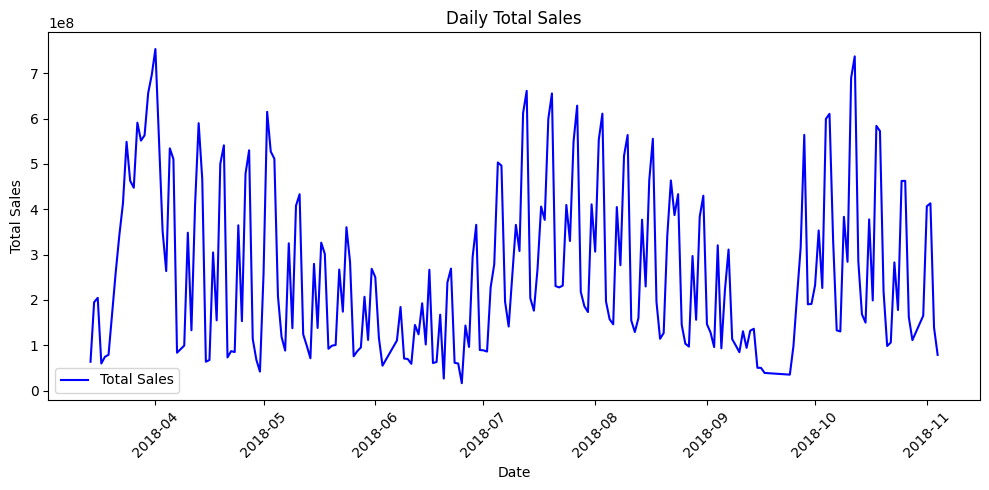

In [8]:
plt.figure(figsize=(10, 5))
plt.plot(df['date'], df['total_sales'], label='Total Sales', color='blue')
plt.title('Daily Total Sales')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

## **3. Prepare Data**
We prepare shifting windows of `sequence_length` continuously.

In [9]:
def create_sequences(data, seq_length):
    xs = []
    ys = []
    for i in range(len(data)-seq_length-1):
        x = data[i:(i+seq_length)]
        y = data[i+seq_length]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

sales_data = df['total_sales'].values.reshape(-1, 1)

seq_length = 9 # Use 9 past days to predict next
X, y = create_sequences(sales_data, seq_length)

# Split into train and test
train_size = int(len(X) * 0.85)
X_train, y_train = X[:train_size], y[:train_size]
X_test, y_test = X[train_size:], y[train_size:]

scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train.reshape(-1, 1)).reshape(X_train.shape)
X_test = scaler.transform(X_test.reshape(-1, 1)).reshape(X_test.shape)
y_train = scaler.transform(y_train.reshape(-1, 1)).reshape(y_train.shape)
y_test = scaler.transform(y_test.reshape(-1, 1)).reshape(y_test.shape)

# Convert NumPy arrays to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train = torch.tensor(y_train, dtype=torch.float32).to(device)
X_test = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test = torch.tensor(y_test, dtype=torch.float32).to(device)

train_data = TensorDataset(X_train, y_train)
test_data = TensorDataset(X_test, y_test)

batch_size = 16
train_loader = DataLoader(train_data, shuffle=False, batch_size=batch_size, drop_last=True)
test_loader = DataLoader(test_data, shuffle=False, batch_size=batch_size, drop_last=True)
print(f"Train samples: {len(train_data)}, Test samples: {len(test_data)}")

Train samples: 180, Test samples: 32


In [10]:
def train_model(model, epochs=100):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.1) # Note: Keeping the learning rate high for demonstrating vanishing gradients in RNNs.

    train_losses = []

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        train_losses.append(epoch_loss/len(train_loader))
        if (epoch+1) % 10 == 0:
            print(f'Epoch {epoch+1}/{epochs}, Loss: {epoch_loss/len(train_loader):.4f}')

    return train_losses

def evaluate_model(model):
    model.eval()
    criterion = nn.MSELoss()
    test_loss = 0
    predictions = []
    actuals = []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            test_loss += loss.item()
            predictions.extend(outputs.cpu().numpy())
            actuals.extend(y_batch.cpu().numpy())
    return test_loss/len(test_loader), predictions, actuals

## **4. Model 0: RNN**

In [11]:
class SimpleRNN(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=1, output_size=1):
        super(SimpleRNN, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)
        self.fc1 = nn.Linear(hidden_size, hidden_size//2)
        self.out = nn.Linear(hidden_size//2, output_size)
        self.activation = nn.GELU()

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        out, _ = self.rnn(x, h0)
        # Get the output from the last timestep
        out = out[:, -1, :]
        out = self.fc1(out)
        out = self.activation(out)
        out = self.out(out)
        return out



rnn_model = SimpleRNN().to(device)
print("Training RNN...")
rnn_train_losses = train_model(rnn_model)
rnn_test_loss, rnn_preds, rnn_actuals = evaluate_model(rnn_model)
print(f'RNN Test Loss: {rnn_test_loss:.4f}')

Training RNN...
Epoch 10/100, Loss: 0.0620
Epoch 20/100, Loss: 0.0623
Epoch 30/100, Loss: 0.0626
Epoch 40/100, Loss: 0.0628
Epoch 50/100, Loss: 0.0629
Epoch 60/100, Loss: 0.0630
Epoch 70/100, Loss: 0.0631
Epoch 80/100, Loss: 0.0631
Epoch 90/100, Loss: 0.0632
Epoch 100/100, Loss: 0.0632
RNN Test Loss: 0.0706


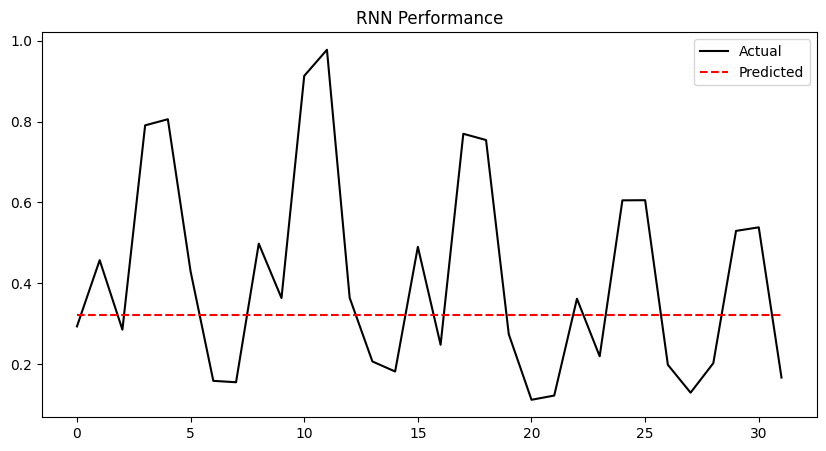

In [12]:
plt.figure(figsize=(10, 5))
plt.plot(rnn_actuals, label='Actual', color='black')
plt.plot(rnn_preds, label='Predicted', color='red', linestyle='--')
plt.title('RNN Performance')
plt.legend()
plt.show()

## **5. Model 1: LSTM**

In [13]:
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=1, output_size=1):
        super(LSTMModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc1 = nn.Linear(hidden_size, hidden_size//2)
        self.out = nn.Linear(hidden_size//2, output_size)
        self.activation = nn.GELU()

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        out, _ = self.lstm(x, (h0, c0))
        out = out[:, -1, :]
        out = self.fc1(out)
        out = self.activation(out)
        out = self.out(out)
        return out

lstm_model = LSTMModel().to(device)
print("Training LSTM...")
lstm_train_losses = train_model(lstm_model)
lstm_test_loss, lstm_preds, lstm_actuals = evaluate_model(lstm_model)
print(f'LSTM Test Loss: {lstm_test_loss:.4f}')

Training LSTM...
Epoch 10/100, Loss: 0.0462
Epoch 20/100, Loss: 0.0313
Epoch 30/100, Loss: 0.0465
Epoch 40/100, Loss: 0.0369
Epoch 50/100, Loss: 0.0373
Epoch 60/100, Loss: 0.0351
Epoch 70/100, Loss: 0.0449
Epoch 80/100, Loss: 0.0213
Epoch 90/100, Loss: 0.0460
Epoch 100/100, Loss: 0.0159
LSTM Test Loss: 0.0264


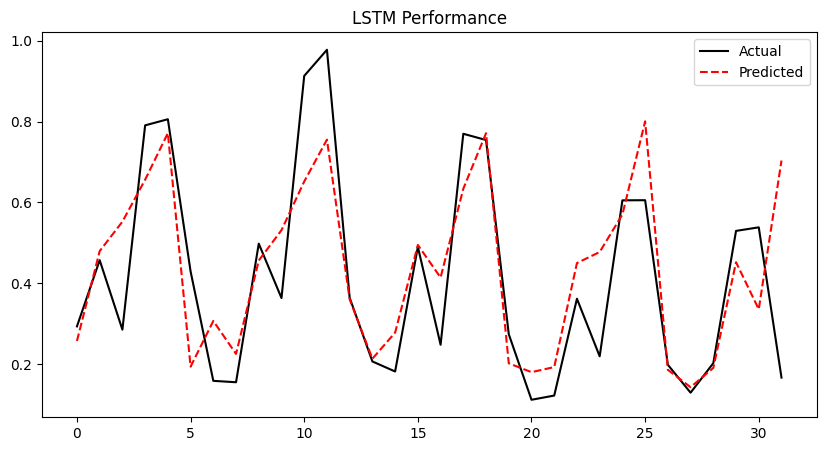

In [14]:
plt.figure(figsize=(10, 5))
plt.plot(lstm_actuals, label='Actual', color='black')
plt.plot(lstm_preds, label='Predicted', color='red', linestyle='--')
plt.title('LSTM Performance')
plt.legend()
plt.show()

## **6. Model 2: GRU**

In [15]:
class GRUModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=1, output_size=1):
        super(GRUModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        self.fc1 = nn.Linear(hidden_size, hidden_size//2)
        self.out = nn.Linear(hidden_size//2, output_size)
        self.activation = nn.GELU()

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        out, _ = self.gru(x, h0)
        out = out[:, -1, :]
        out = self.fc1(out)
        out = self.activation(out)
        out = self.out(out)
        return out

gru_model = GRUModel().to(device)
print("Training GRU...")
gru_train_losses = train_model(gru_model)
gru_test_loss, gru_preds, gru_actuals = evaluate_model(gru_model)
print(f'GRU Test Loss: {gru_test_loss:.4f}')

Training GRU...
Epoch 10/100, Loss: 0.0627
Epoch 20/100, Loss: 0.0631
Epoch 30/100, Loss: 0.0810
Epoch 40/100, Loss: 0.0632
Epoch 50/100, Loss: 0.0561
Epoch 60/100, Loss: 0.0633
Epoch 70/100, Loss: 0.0633
Epoch 80/100, Loss: 0.0633
Epoch 90/100, Loss: 0.0633
Epoch 100/100, Loss: 0.0634
GRU Test Loss: 0.0707


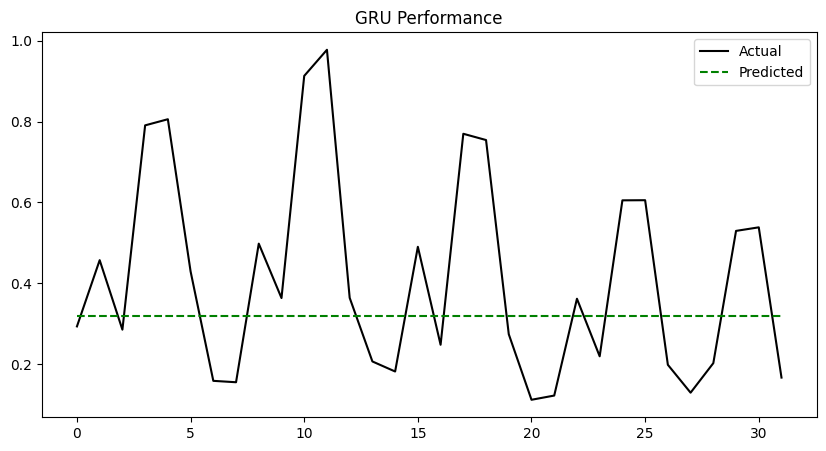

In [16]:
plt.figure(figsize=(10, 5))
plt.plot(gru_actuals, label='Actual', color='black')
plt.plot(gru_preds, label='Predicted', color='green', linestyle='--')
plt.title('GRU Performance')
plt.legend()
plt.show()

## **7. Compare Models**

In [17]:
print(f"RNN Test Loss:  {rnn_test_loss:.4f}")
print(f"LSTM Test Loss: {lstm_test_loss:.4f}")
print(f"GRU Test Loss:  {gru_test_loss:.4f}")

RNN Test Loss:  0.0706
LSTM Test Loss: 0.0264
GRU Test Loss:  0.0707


In [18]:
rnn_r2 = r2_score(rnn_actuals, rnn_preds)
lstm_r2 = r2_score(lstm_actuals, lstm_preds)
gru_r2 = r2_score(gru_actuals, gru_preds)
print(f"RNN R² Score:  {rnn_r2:.4f}")
print(f"LSTM R² Score: {lstm_r2:.4f}")
print(f"GRU R² Score:  {gru_r2:.4f}")

RNN R² Score:  -0.1365
LSTM R² Score: 0.5754
GRU R² Score:  -0.1380


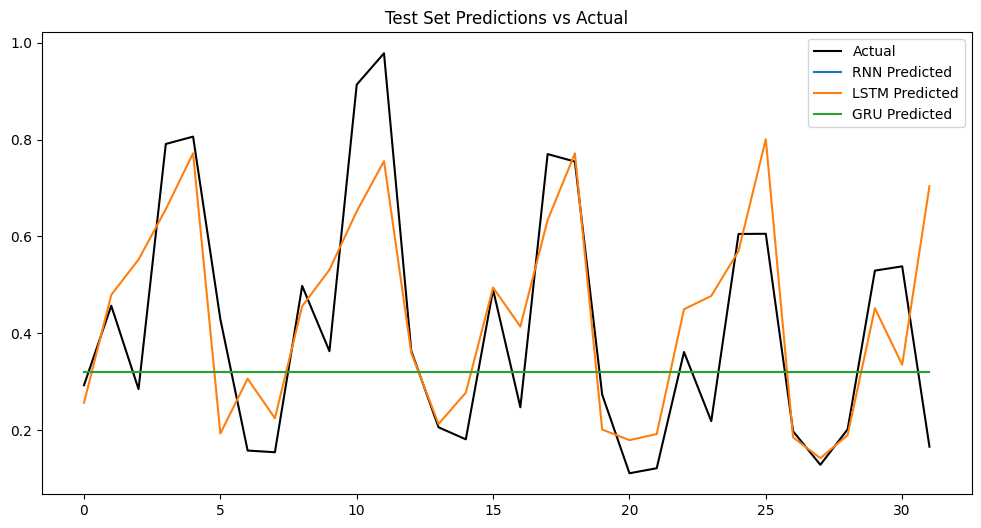

In [19]:


plt.figure(figsize=(12, 6))
plt.plot(rnn_actuals, label='Actual', color='black')
plt.plot(rnn_preds, label='RNN Predicted')
plt.plot(lstm_preds, label='LSTM Predicted')
plt.plot(gru_preds, label='GRU Predicted')
plt.title('Test Set Predictions vs Actual')
plt.legend()
plt.show()